# Лабораторная работа 4

Построение парной линейной регрессии на основе данных выборки и выбор одного фактора с максимальным коэффициентом частной корреляции.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')

data = pd.read_csv('lab4_synthetic_data.csv')
data.head()

,id,x1,x2,x3,x4,y
0,1,-0.214,1.434,0.201,0.582,6.524
1,2,-0.355,-0.229,-0.347,1.107,4.222
2,3,0.933,-0.170,1.451,-0.444,11.509
3,4,0.582,0.119,0.549,-1.207,8.696
4,5,-1.224,1.089,-1.003,0.922,1.613


In [ ]:
target = 'y'
predictors = ['x1', 'x2', 'x3', 'x4']

partial_rows = []
for predictor in predictors:
    others = [name for name in predictors if name != predictor]

    design_others = np.column_stack([np.ones(len(data)), data[others].to_numpy()])
    beta_y, *_ = np.linalg.lstsq(design_others, data[target].to_numpy(), rcond=None)
    resid_y = data[target].to_numpy() - design_others @ beta_y

    design_x = np.column_stack([np.ones(len(data)), data[others].to_numpy()])
    beta_x, *_ = np.linalg.lstsq(design_x, data[predictor].to_numpy(), rcond=None)
    resid_x = data[predictor].to_numpy() - design_x @ beta_x

    pcorr = np.corrcoef(resid_y, resid_x)[0, 1]
    partial_rows.append({'фактор': predictor, 'частная корреляция': pcorr, 'абсолютное значение': abs(pcorr)})

partial_table = pd.DataFrame(partial_rows).sort_values('абсолютное значение', ascending=False).reset_index(drop=True)
best_x = partial_table.loc[0, 'фактор']
partial_table

,фактор,частная корреляция,абсолютное значение
0,x3,0.693847,0.693847
1,x1,0.579273,0.579273
2,x2,0.386671,0.386671
3,x4,0.130341,0.130341


## Парная линейная регрессия

Фактор с максимальным коэффициентом частной корреляции используется как объясняющая переменная в модели $y = a_0 + a_1 x$.

In [7]:
x = data[best_x].to_numpy()
y = data[target].to_numpy()
n = len(data)

mean_x = x.mean()
mean_y = y.mean()
sxx = ((x - mean_x) ** 2).sum()
syy = ((y - mean_y) ** 2).sum()
sxy = ((x - mean_x) * (y - mean_y)).sum()

a1 = sxy / sxx
a0 = mean_y - a1 * mean_x
y_hat = a0 + a1 * x
residuals = y - y_hat
sse = (residuals ** 2).sum()
mse = sse / (n - 2)
s = np.sqrt(mse)
se_a1 = np.sqrt(mse / sxx)
se_a0 = np.sqrt(mse * (1 / n + mean_x ** 2 / sxx))
t_a1 = a1 / se_a1
t_a0 = a0 / se_a0
r2 = 1 - sse / syy
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - 2)
f_stat = (r2 / 1) / ((1 - r2) / (n - 2))
p_value_f = stats.f.sf(f_stat, 1, n - 2)

model_summary = pd.DataFrame({
    'показатель': ['лучший фактор', 'a0', 'a1', 's(a0)', 's(a1)', 't(a0)', 't(a1)', 'R^2', 'R^2 adj', 'F', 'p(F)'],
    'значение': [best_x, a0, a1, se_a0, se_a1, t_a0, t_a1, r2, adj_r2, f_stat, p_value_f]
})

model_summary

,показатель,значение
0,лучший фактор,x3
1,a0,5.535143
2,a1,3.862388
3,s(a0),0.049187
4,s(a1),0.059216
5,t(a0),112.531876
6,t(a1),65.225069
7,R^2,0.98655
8,R^2 adj,0.986318
9,F,4254.309611


## График и диагностика

Построим линию регрессии, оценим остатки и проверим их распределение.

Выбранный фактор: x3
Уравнение регрессии: y = 5.5351 + 3.8624 * x3
p-value теста Шапиро-Уилка для остатков: 0.0258


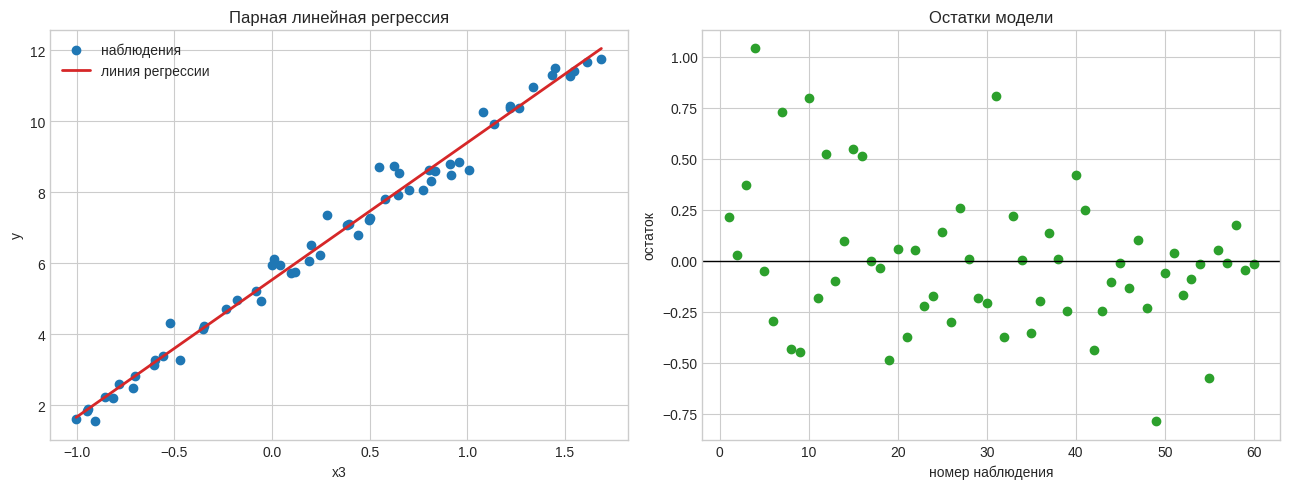

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(x, y, color='#1f77b4', label='наблюдения')
order = np.argsort(x)
axes[0].plot(x[order], y_hat[order], color='#d62728', linewidth=2, label='линия регрессии')
axes[0].set_xlabel(best_x)
axes[0].set_ylabel(target)
axes[0].set_title('Парная линейная регрессия')
axes[0].legend()

axes[1].axhline(0, color='black', linewidth=1)
axes[1].scatter(range(1, n + 1), residuals, color='#2ca02c')
axes[1].set_xlabel('номер наблюдения')
axes[1].set_ylabel('остаток')
axes[1].set_title('Остатки модели')

plt.tight_layout()

shapiro_w, shapiro_p = stats.shapiro(residuals)

print(f'Выбранный фактор: {best_x}')
print(f'Уравнение регрессии: y = {a0:.4f} + {a1:.4f} * {best_x}')
print(f'p-value теста Шапиро-Уилка для остатков: {shapiro_p:.4f}')